In [2]:
import torch
import subprocess
import random
import matplotlib.pyplot as plt
import numpy as np
import pyautogui
import time

device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: mps


In [32]:
# Setting model hyperparameters
gamma = 0.99            # Discount factor for future rewards
epsilon = 1.0           # Initial exploration rate
epsilon_decay = 0.995   # Decay rate for the exploration probability per episode
min_epsilon = 0.01      # Minimum exploration rate
learning_rate = 0.001   # Rate at which model changes parameters
num_episodes = 1000     # Number of episodes to engage in

# Action mapping for emulator
ACTION_MAP = {
    'A': 'x',
    'B': 'z',
    'X': 's',
    'Y': 'a',
    'Up': 'up',
    'Down': 'down',
    'Left': 'left',
    'Right': 'right'
}

#### Examining how epsilon (exploration rate) changes through episodes (training)

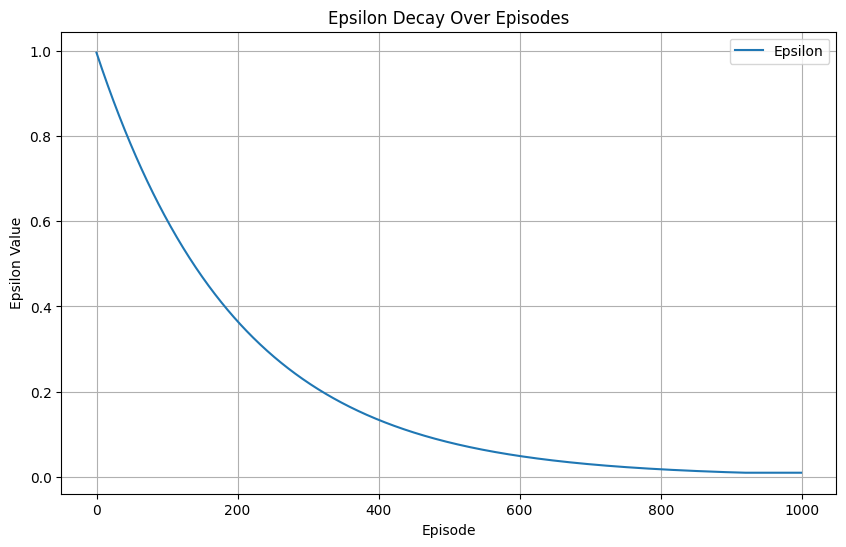

In [36]:
# List to store epsilon values
epsilon_values = []

# Simulate epsilon decay over episodes
for episode in range(num_episodes):
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    epsilon_values.append(epsilon)

# Plotting the epsilon decay
plt.figure(figsize=(10, 6))
plt.plot(epsilon_values, label='Epsilon')
plt.xlabel('Episode')
plt.ylabel('Epsilon Value')
plt.title('Epsilon Decay Over Episodes')
plt.legend()
plt.grid(True)
plt.show()


### Loading the pretrained model

In [ ]:
# Load the trained model
model_path = 'models/pokemon_model_lstm.pth'
model = torch.load(model_path)
model.load_state_dict()
model.eval()

### Connecting script to emulator (DeSmuME)

In [ ]:
# Path to the DeSmuME executable and the ROM file
desmume_executable = '/Applications/DeSmuME.app'
pokemon_rom = '/path/to/pokemon_rom.nds'

# Start DeSmuME emulator
subprocess.Popen([desmume_executable, pokemon_rom])

# Wait for the emulator to start
time.sleep(2) 

In [ ]:
# Functions to interact with the emulator

def get_game_state(output_dir='game_state_screenshots', frame_num=0):
    """Function to capture the current game state from the emulator"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    screenshot = pyautogui.screenshot()
    frame_path = os.path.join(output_dir, f'frame_{frame_num}.png')
    screenshot.save(frame_path)
    print(f"Saved game state to {frame_path}")

def perform_action(action):
    """Function to perform the given action in the emulator."""
    if action in ACTION_MAP:
        key = ACTION_MAP[action]
        pyautogui.press(key)
        time.sleep(0.1)  # Adding a short delay to ensure the action is registered

### Defining Rewards

In [ ]:
def calculate_reward(state, action, next_state):
    reward = 0
    if next_state['win']:
        reward += 10
    elif next_state['loss']:
        reward -= 10
    return reward


### Collecting Human Feedback

In [ ]:
def get_human_feedback(states, actions):
    feedback = []
    for state, action in zip(states, actions):
        # Display state and action to the human for feedback
        print(f"State: {state}, Action: {action}")
        fb = input("Is this action correct? (yes/no): ")
        feedback.append(1 if fb.lower() == 'yes' else 0)
    return feedback
